# PlantVillage Disease Classification — DenseNet169 + Two-Stage Visual Inference

This notebook fine-tunes a **DenseNet169** backbone on the **PlantVillage** leaf-disease
dataset, then wraps the trained classifier in a **two-stage inference pipeline**:

1. **Stage 1 — Localization:** find the leaf/object bounding box in a raw photo (YOLOv8n,
   with an OpenCV contour-based fallback — see the honesty note in Section 6).
2. **Stage 2 — Classification:** crop that region, run it through DenseNet169, and report the
   top-1 label with confidence plus a Top-5 bar chart.

**Runtime:** Colab, GPU runtime recommended (`Runtime → Change runtime type → T4 GPU`).

**Before you run:** you need a free Kaggle account and API token
(`kaggle.com → Account → Create New API Token`, downloads `kaggle.json`). You'll be prompted
to upload it in Section 1. You must also accept the dataset's terms once on the
[PlantVillage Kaggle page](https://www.kaggle.com/datasets/emmarex/plantdisease) if you haven't
already — the API download fails silently on unaccepted terms otherwise.

Run the cells top to bottom. Nothing here needs manual edits to work, though the constants
called out in each section (epochs, batch size, val split, etc.) are yours to tune.

## 1. Environment Setup & Data Acquisition

Installs the libraries the rest of the notebook depends on, authenticates against the Kaggle
API, downloads the PlantVillage mirror (`emmarex/plantdisease`), and builds an 80/20
train/val split from its per-class folders.

Colab ships with `torch`/`torchvision` preinstalled and CUDA-linked, so the install below
just confirms the versions rather than forcing a reinstall — forcing one risks pulling a
CPU-only build that breaks the existing CUDA linkage.

In [1]:
!pip install -q torch torchvision torchaudio
!pip install -q ultralytics opencv-python matplotlib kaggle

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 6.5 MB/s eta 0:00:00


In [2]:
import os
import json
import random
import shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler

from torchvision import transforms
from torchvision.models import densenet169, DenseNet169_Weights
from torchvision.datasets import ImageFolder

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
if DEVICE.type != 'cuda':
    print("WARNING: no GPU detected. Go to Runtime -> Change runtime type -> T4 GPU, "
          "or training/mixed-precision below will be very slow / a no-op.")

Using device: cuda


### Kaggle API credentials

Run the next cell and select your `kaggle.json` when prompted (skip the upload if it's
already configured from a previous session in this runtime).

In [3]:
from google.colab import files

KAGGLE_JSON_PATH = Path.home() / '.kaggle' / 'kaggle.json'

if not KAGGLE_JSON_PATH.exists():
    print("Upload your kaggle.json (Kaggle -> Account -> Create New API Token):")
    uploaded = files.upload()
    if 'kaggle.json' not in uploaded:
        raise FileNotFoundError("kaggle.json was not uploaded. Re-run this cell and select the file.")
    KAGGLE_JSON_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(KAGGLE_JSON_PATH, 'wb') as f:
        f.write(uploaded['kaggle.json'])
    os.chmod(KAGGLE_JSON_PATH, 0o600)
else:
    print("kaggle.json already configured for this runtime.")

Upload your kaggle.json (Kaggle -> Account -> Create New API Token):


Saving kaggle.json to kaggle.json


In [4]:
DATA_ROOT = Path('/content/plantvillage_data')
RAW_DIR = DATA_ROOT / 'raw'
RAW_DIR.mkdir(parents=True, exist_ok=True)

KAGGLE_DATASET_SLUG = "emmarex/plantdisease"  # PlantVillage mirror on Kaggle

if not any(RAW_DIR.iterdir()):
    print(f"Downloading {KAGGLE_DATASET_SLUG} from Kaggle (this can take a few minutes)...")
    exit_code = os.system(f"kaggle datasets download -d {KAGGLE_DATASET_SLUG} -p {RAW_DIR} --unzip")
    if exit_code != 0:
        raise RuntimeError(
            "Kaggle download failed. Confirm kaggle.json is valid and that you've accepted "
            "the dataset's terms at https://www.kaggle.com/datasets/emmarex/plantdisease"
        )
    print("Download complete.")
else:
    print("Raw dataset already present in this runtime, skipping download.")

Download complete.


In [5]:
def find_class_root(root: Path) -> Path:
    """
    Kaggle mirrors of PlantVillage nest the per-class folders at slightly different depths
    depending on how the zip was packaged (e.g. raw/PlantVillage/<class>/*.jpg vs
    raw/PlantVillage/PlantVillage/<class>/*.jpg). Walk the extracted tree and return the
    directory with the most subfolders that are themselves full of images -- that's the
    real class-folder root regardless of nesting depth.
    """
    image_ext = {'.jpg', '.jpeg', '.png'}
    candidates = []
    for dirpath, dirnames, _ in os.walk(root):
        if len(dirnames) < 2:
            continue
        sample_dir = Path(dirpath) / dirnames[0]
        try:
            sample_files = os.listdir(sample_dir)[:20]
        except (FileNotFoundError, NotADirectoryError):
            continue
        has_images = any(Path(f).suffix.lower() in image_ext for f in sample_files)
        if has_images:
            candidates.append((len(dirnames), Path(dirpath)))
    if not candidates:
        raise FileNotFoundError(f"Could not locate class-labelled image folders under {root}")
    candidates.sort(reverse=True)
    return candidates[0][1]


CLASS_ROOT = find_class_root(RAW_DIR)
class_dirs_found = sorted(d.name for d in CLASS_ROOT.iterdir() if d.is_dir())
print(f"Detected class-folder root: {CLASS_ROOT}")
print(f"Classes found ({len(class_dirs_found)}): {class_dirs_found[:5]} ...")

Detected class-folder root: /content/plantvillage_data/raw/plantvillage/PlantVillage
Classes found (15): ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy'] ...


In [6]:
TRAIN_DIR = DATA_ROOT / 'train'
VAL_DIR = DATA_ROOT / 'val'
VAL_SPLIT = 0.2


def build_train_val_split(class_root: Path, train_dir: Path, val_dir: Path,
                           val_split: float = 0.2, seed: int = SEED):
    """
    Splits each class folder 80/20 into train_dir/<class>/ and val_dir/<class>/.
    Uses symlinks (falling back to a real copy if the filesystem doesn't support them) so the
    split is fast and doesn't double the on-disk dataset size.
    """
    if train_dir.exists() and val_dir.exists():
        print("Train/val split already exists in this runtime, skipping.")
        return
    train_dir.mkdir(parents=True, exist_ok=True)
    val_dir.mkdir(parents=True, exist_ok=True)
    rng = random.Random(seed)
    image_ext = {'.jpg', '.jpeg', '.png'}
    class_paths = [d for d in class_root.iterdir() if d.is_dir()]

    for class_dir in class_paths:
        images = [p for p in class_dir.iterdir() if p.suffix.lower() in image_ext]
        rng.shuffle(images)
        split_idx = int(len(images) * (1 - val_split))
        train_images, val_images = images[:split_idx], images[split_idx:]

        (train_dir / class_dir.name).mkdir(parents=True, exist_ok=True)
        (val_dir / class_dir.name).mkdir(parents=True, exist_ok=True)

        for img in train_images:
            dest = train_dir / class_dir.name / img.name
            try:
                os.symlink(img.resolve(), dest)
            except OSError:
                shutil.copyfile(img, dest)
        for img in val_images:
            dest = val_dir / class_dir.name / img.name
            try:
                os.symlink(img.resolve(), dest)
            except OSError:
                shutil.copyfile(img, dest)

    n_train = sum(1 for _ in train_dir.rglob('*.*'))
    n_val = sum(1 for _ in val_dir.rglob('*.*'))
    print(f"Split complete -> train: {n_train} images, val: {n_val} images "
          f"across {len(class_paths)} classes")


build_train_val_split(CLASS_ROOT, TRAIN_DIR, VAL_DIR, VAL_SPLIT)

Split complete -> train: 16504 images, val: 4134 images across 15 classes


## 2. Data Preprocessing & Augmentation

Standard ImageNet-style pipeline since DenseNet169 is ImageNet-pretrained: light geometric
and color augmentation on train, deterministic resize + normalize on val.

In [7]:
IMG_SIZE = (224, 224)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = ImageFolder(root=str(TRAIN_DIR), transform=train_transforms)
val_dataset = ImageFolder(root=str(VAL_DIR), transform=val_transforms)

assert train_dataset.classes == val_dataset.classes, "Train/val class ordering mismatch"
NUM_CLASSES = len(train_dataset.classes)
IDX_TO_CLASS = {v: k for k, v in train_dataset.class_to_idx.items()}

print(f"Num classes: {NUM_CLASSES}")
print(f"Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}")

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)

Num classes: 15
Train samples: 16504 | Val samples: 4134


## 3. Model Architecture & Transfer Learning

Loads ImageNet-pretrained DenseNet169, freezes the convolutional feature extractor
(`model.features`), and replaces the classifier head with a small trainable MLP sized for
`NUM_CLASSES`. Only the new head trains — this is feature-extraction transfer learning, not
full fine-tuning, which is the right call for a first pass given how little data 15-epoch
training actually needs to touch when the backbone is frozen.

In [8]:
weights = DenseNet169_Weights.DEFAULT
model = densenet169(weights=weights)

for param in model.features.parameters():
    param.requires_grad = False

model.classifier = nn.Sequential(
    nn.Linear(1664, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, NUM_CLASSES),
)

model = model.to(DEVICE)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable_params:,} / {total_params:,} total")
print(model.classifier)

Downloading: "https://download.pytorch.org/models/densenet169-b2777c0a.pth" to /root/.cache/torch/hub/checkpoints/densenet169-b2777c0a.pth


100%|██████████| 54.7M/54.7M [00:00<00:00, 82.3MB/s]


Trainable params: 860,175 / 13,344,655 total
Sequential(
  (0): Linear(in_features=1664, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=512, out_features=15, bias=True)
)


## 4. Training Loop & Validation Engine

AdamW on the (unfrozen) classifier head, `ReduceLROnPlateau` tracking validation accuracy,
and automatic mixed precision (`autocast` + `GradScaler`) to make better use of the T4's
Tensor Cores. The best-val-accuracy checkpoint is written to disk after every improving
epoch, so the notebook is safe to interrupt without losing the best model.

`NUM_EPOCHS = 15` is a reasonable starting point for a frozen-backbone head on ~54k images;
raise it if `val_acc` is still climbing when training ends.

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
scaler = GradScaler(enabled=(DEVICE.type == 'cuda'))

NUM_EPOCHS = 15
CHECKPOINT_PATH = Path('/content/densenet169_plantvillage.pth')


def run_epoch(loader, train_mode: bool):
    model.train() if train_mode else model.eval()
    running_loss, running_correct, total = 0.0, 0, 0
    grad_context = torch.enable_grad() if train_mode else torch.no_grad()
    with grad_context:
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if train_mode:
                optimizer.zero_grad(set_to_none=True)

            with autocast(enabled=(DEVICE.type == 'cuda')):
                outputs = model(images)
                loss = criterion(outputs, labels)

            if train_mode:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            running_loss += loss.item() * images.size(0)
            running_correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += images.size(0)

    return running_loss / total, running_correct / total


history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train_mode=True)
    val_loss, val_acc = run_epoch(val_loader, train_mode=False)
    scheduler.step(val_acc)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | lr={current_lr:.2e}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"  -> new best val_acc={best_val_acc:.4f}, checkpoint saved to {CHECKPOINT_PATH}")

print(f"\nTraining complete. Best val_acc={best_val_acc:.4f}")

/tmp/ipykernel_604/3425686925.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(DEVICE.type == 'cuda'))
/tmp/ipykernel_604/3425686925.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):


Epoch 01/15 | train_loss=0.6122 train_acc=0.8081 | val_loss=0.2502 val_acc=0.9284 | lr=1.00e-03
  -> new best val_acc=0.9284, checkpoint saved to /content/densenet169_plantvillage.pth
Epoch 02/15 | train_loss=0.2860 train_acc=0.9038 | val_loss=0.1807 val_acc=0.9383 | lr=1.00e-03
  -> new best val_acc=0.9383, checkpoint saved to /content/densenet169_plantvillage.pth
Epoch 03/15 | train_loss=0.2520 train_acc=0.9140 | val_loss=0.1711 val_acc=0.9417 | lr=1.00e-03
  -> new best val_acc=0.9417, checkpoint saved to /content/densenet169_plantvillage.pth


/tmp/ipykernel_604/3425686925.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_604/3425686925.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_604/3425686925.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_604/3425686925.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_604/3425686925.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


Epoch 04/15 | train_loss=0.2143 train_acc=0.9276 | val_loss=0.2214 val_acc=0.9211 | lr=1.00e-03


/tmp/ipykernel_604/3425686925.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_604/3425686925.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_604/3425686925.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_604/3425686925.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_604/3425686925.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


...

Epoch 13/15 | train_loss=0.1032 train_acc=0.9641 | val_loss=0.0877 val_acc=0.9686 | lr=5.00e-04
  -> new best val_acc=0.9686, checkpoint saved to /content/densenet169_plantvillage.pth


/tmp/ipykernel_604/3425686925.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_604/3425686925.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_604/3425686925.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_604/3425686925.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_604/3425686925.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


Epoch 14/15 | train_loss=0.1007 train_acc=0.9653 | val_loss=0.0973 val_acc=0.9669 | lr=5.00e-04


/tmp/ipykernel_604/3425686925.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_604/3425686925.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_604/3425686925.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_604/3425686925.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_604/3425686925.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


Epoch 15/15 | train_loss=0.0978 train_acc=0.9675 | val_loss=0.1135 val_acc=0.9579 | lr=5.00e-04

Training complete. Best val_acc=0.9686


Quick sanity check on the training curves — watch for the val curve diverging from
train (overfitting) or plateauing early (learning rate or capacity limited).

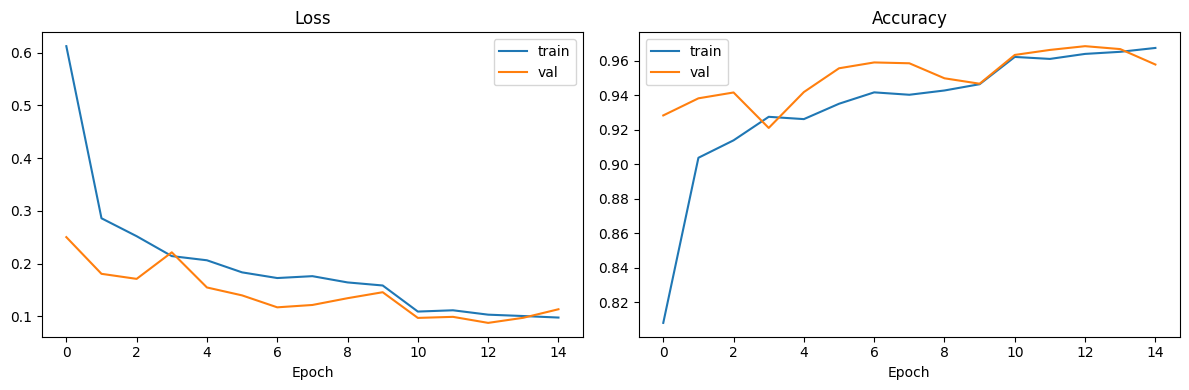

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['train_acc'], label='train')
axes[1].plot(history['val_acc'], label='val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Artifact Export

Persists the two artifacts the inference pipeline needs: the best-val-accuracy weights and
the index-to-class-name mapping. The model is then reloaded from the checkpoint (not just
left at its post-training state) so inference always runs the *best* epoch, not whichever
epoch training happened to end on.

In [11]:
CLASS_MAPPING_PATH = Path('/content/class_mapping.json')

with open(CLASS_MAPPING_PATH, 'w') as f:
    json.dump(IDX_TO_CLASS, f, indent=2)

print(f"Best model weights: {CHECKPOINT_PATH}")
print(f"Class mapping:      {CLASS_MAPPING_PATH}")

model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.eval()
print("Reloaded best checkpoint for inference.")

Best model weights: /content/densenet169_plantvillage.pth
Class mapping:      /content/class_mapping.json
Reloaded best checkpoint for inference.


Optional: download both artifacts to your local machine (uncomment to run).

In [12]:
# from google.colab import files as colab_files
# colab_files.download(str(CHECKPOINT_PATH))
# colab_files.download(str(CLASS_MAPPING_PATH))

## 6. Two-Stage Visual Inference Pipeline (Leaf BBox + Prediction Overlay)

**Honesty note on Stage 1:** `yolov8n.pt` ships COCO-pretrained, and COCO has no `leaf` or
`plant` class — so YOLO alone will only ever fire on generic objects it happens to recognize
in the frame, which is rare for a PlantVillage-style close-up. `detect_leaf_bbox` below tries
YOLO first and falls back to an OpenCV Otsu-threshold contour detector, which is what
actually does the localization work for these images (single leaf, largely uniform
background). YOLO is kept in the loop because it's the one piece of this stage that
generalizes to messier, real-world field photos with an actual object present — for
PlantVillage's controlled images specifically, expect the contour fallback to fire most of
the time, and that's fine.

In [13]:
from ultralytics import YOLO

_yolo_model = None


def get_yolo_model():
    global _yolo_model
    if _yolo_model is None:
        _yolo_model = YOLO('yolov8n.pt')  # downloads COCO-pretrained weights on first use
    return _yolo_model


def detect_leaf_bbox_contour(image_bgr: np.ndarray, padding: int = 10):
    """
    Fallback localizer for PlantVillage-style images (single leaf, mostly uniform
    background). Otsu-thresholds the grayscale image (and its inverse, since PlantVillage
    backgrounds vary between lighter- and darker-than-leaf) and returns the bounding box of
    whichever largest contour looks leaf-sized rather than background-sized or noise-sized.
    """
    h, w = image_bgr.shape[:2]
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    best_box, best_score = None, -1.0
    for mask in (thresh, cv2.bitwise_not(thresh)):
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue
        largest = max(contours, key=cv2.contourArea)
        area_ratio = cv2.contourArea(largest) / (h * w)
        if 0.05 < area_ratio < 0.98 and area_ratio > best_score:
            best_score = area_ratio
            x, y, bw, bh = cv2.boundingRect(largest)
            best_box = (
                max(x - padding, 0),
                max(y - padding, 0),
                min(x + bw + padding, w),
                min(y + bh + padding, h),
            )

    if best_box is None:
        best_box = (0, 0, w, h)  # nothing usable segmented out -> treat whole frame as ROI
    return best_box


def detect_leaf_bbox(image_bgr: np.ndarray, use_yolo: bool = True, yolo_conf: float = 0.25):
    """
    Stage 1: localize the primary leaf/object in the frame. Tries YOLOv8n first, falls back
    to the contour segmenter (see the honesty note above this cell).
    """
    if use_yolo:
        try:
            results = get_yolo_model().predict(image_bgr, conf=yolo_conf, verbose=False)
            boxes = results[0].boxes
            if boxes is not None and len(boxes) > 0:
                areas = (boxes.xyxy[:, 2] - boxes.xyxy[:, 0]) * (boxes.xyxy[:, 3] - boxes.xyxy[:, 1])
                best_idx = int(areas.argmax())
                x1, y1, x2, y2 = boxes.xyxy[best_idx].tolist()
                return int(x1), int(y1), int(x2), int(y2)
        except Exception as exc:
            print(f"YOLO detection failed ({exc}); falling back to contour method.")
    return detect_leaf_bbox_contour(image_bgr)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [14]:
def predict_and_annotate(image_path, model, class_mapping, use_yolo: bool = True, top_k: int = 5):
    """
    Full two-stage pipeline: Stage 1 localizes the leaf, Stage 2 classifies the crop.
    Returns (annotated_bgr_image, top_k_predictions) where top_k_predictions is a list of
    (class_name, probability) tuples sorted by descending probability.
    """
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f"Could not read image at {image_path}")

    x1, y1, x2, y2 = detect_leaf_bbox(image_bgr, use_yolo=use_yolo)
    roi_bgr = image_bgr[y1:y2, x1:x2]
    if roi_bgr.size == 0:
        roi_bgr = image_bgr  # degenerate box guard

    roi_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB)
    roi_pil = Image.fromarray(roi_rgb)
    input_tensor = val_transforms(roi_pil).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        with autocast(enabled=(DEVICE.type == 'cuda')):
            logits = model(input_tensor)
        probs = torch.softmax(logits, dim=1).squeeze(0).float().cpu()

    k = min(top_k, probs.numel())
    top_probs, top_indices = torch.topk(probs, k=k)
    top_predictions = [(class_mapping[int(idx)], float(p)) for idx, p in zip(top_indices, top_probs)]

    label, confidence = top_predictions[0]
    label_text = f"{label}: {confidence * 100:.1f}%"

    annotated = image_bgr.copy()
    box_color = (46, 204, 113)  # vibrant green, BGR
    cv2.rectangle(annotated, (x1, y1), (x2, y2), box_color, thickness=3)

    (text_w, text_h), baseline = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
    banner_y1 = max(y1 - text_h - baseline - 10, 0)
    cv2.rectangle(annotated, (x1, banner_y1), (x1 + text_w + 10, y1), box_color, thickness=-1)
    cv2.putText(
        annotated, label_text, (x1 + 5, y1 - baseline - 5),
        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), thickness=2, lineType=cv2.LINE_AA,
    )

    return annotated, top_predictions

In [15]:
def show_prediction(image_path, model, class_mapping, use_yolo: bool = True):
    """Runs the pipeline and renders the annotated image next to a Top-5 confidence bar chart."""
    annotated_bgr, top_predictions = predict_and_annotate(image_path, model, class_mapping, use_yolo=use_yolo)
    annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

    labels = [name for name, _ in top_predictions][::-1]
    scores = [prob * 100 for _, prob in top_predictions][::-1]

    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [3, 2]})

    ax_img.imshow(annotated_rgb)
    ax_img.axis('off')
    ax_img.set_title('Detected Leaf + Prediction')

    ax_bar.barh(labels, scores, color='#2ecc71')
    ax_bar.set_xlabel('Confidence (%)')
    ax_bar.set_xlim(0, 100)
    ax_bar.set_title('Top-5 Predicted Classes')
    for i, score in enumerate(scores):
        ax_bar.text(score + 1, i, f"{score:.1f}%", va='center')

    plt.tight_layout()
    plt.show()
    return top_predictions

### Run it

First on a validation-set image as a sanity check, then optionally on your own upload.

Running inference on: /content/plantvillage_data/val/Tomato_healthy/d41e126d-fc0d-4224-96e0-2d5ae074e4ac___RS_HL 9933.JPG


/tmp/ipykernel_604/311438530.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):


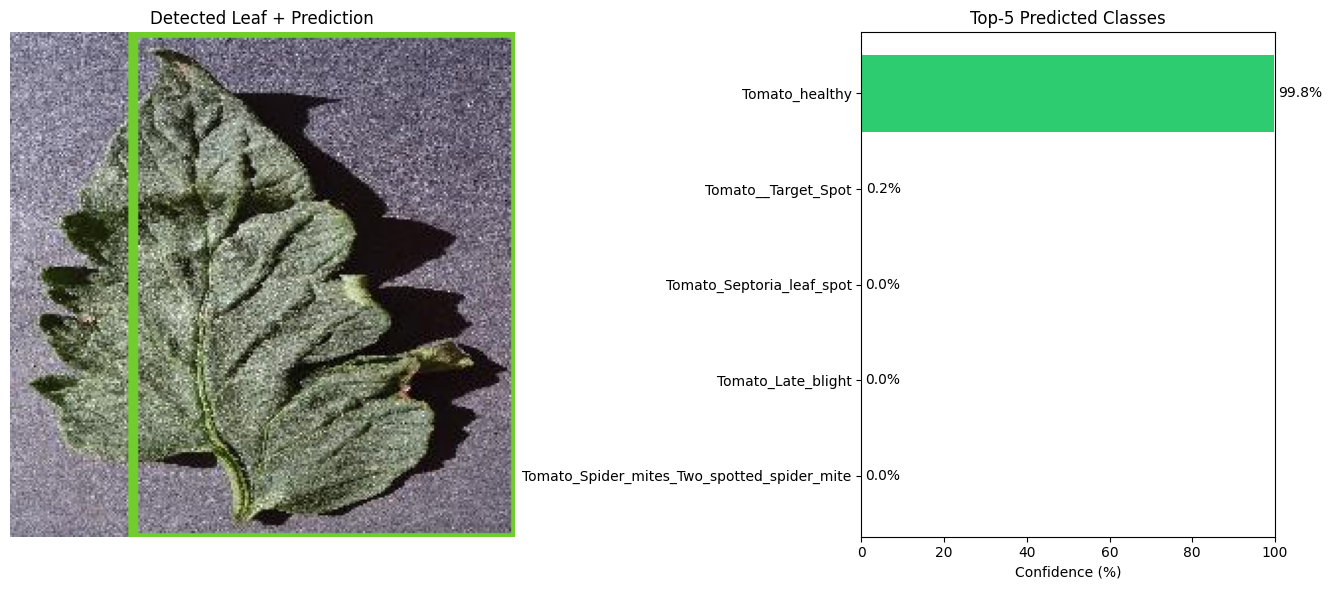

In [16]:
with open(CLASS_MAPPING_PATH, 'r') as f:
    class_mapping = {int(k): v for k, v in json.load(f).items()}  # JSON keys load as strings

sample_class_dir = next(VAL_DIR.iterdir())
sample_image_path = next(sample_class_dir.glob('*.*'))
print(f"Running inference on: {sample_image_path}")

_ = show_prediction(sample_image_path, model, class_mapping, use_yolo=True)

In [17]:
# Optional: upload your own photo and run the same pipeline on it.
from google.colab import files as colab_files

uploaded_image = colab_files.upload()
if uploaded_image:
    custom_image_path = next(iter(uploaded_image.keys()))
    _ = show_prediction(custom_image_path, model, class_mapping, use_yolo=True)
else:
    print("No file uploaded, skipping.")

No file uploaded, skipping.


## Notes & Next Steps

- **Epochs / capacity:** `NUM_EPOCHS = 15` trains only the classifier head. If `val_acc` is
  still rising at the end, either raise `NUM_EPOCHS` or unfreeze the last DenseNet block
  (`model.features.denseblock4`) for a low-LR fine-tuning pass once the head has converged.
- **Class imbalance:** PlantVillage's 38 classes aren't evenly sized. If certain classes
  underperform, check `train_dataset.targets` counts per class and consider a weighted
  sampler or class-weighted loss.
- **Stage 1 in the wild:** see the honesty note above Section 6 — the contour fallback is
  tuned for PlantVillage's plain backgrounds, not field photos with clutter, multiple leaves,
  or complex lighting. A leaf-specific detector (fine-tuned YOLO on annotated field images)
  would be the real fix if this pipeline needs to run on uncontrolled photos.
- **Batch inference:** `predict_and_annotate` takes one path at a time; wrap it in a loop over
  a directory (`Path(dir).glob('*.jpg')`) for batch runs, saving `annotated` with
  `cv2.imwrite` instead of `plt.show()`.